In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [11]:
df.isnull().sum()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

In [12]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


<Axes: xlabel='cgpa', ylabel='Count'>

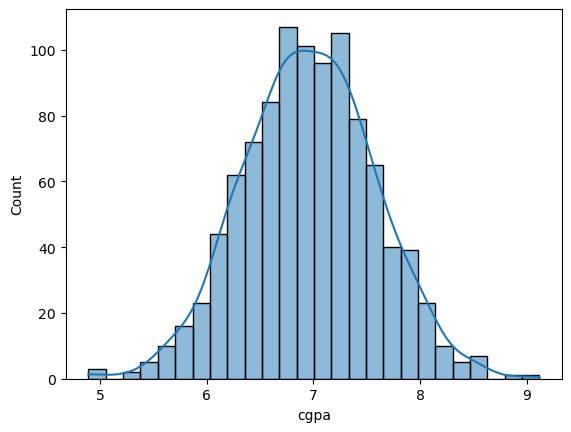

In [6]:
sns.histplot(df['cgpa'],kde=True)

In [7]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

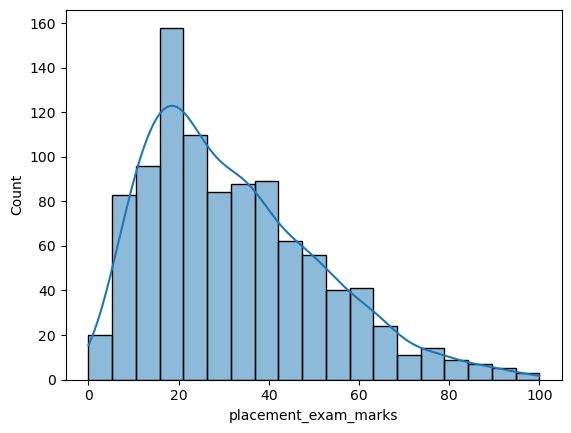

In [8]:
sns.histplot(df['placement_exam_marks'],kde=True)

In [9]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [ ]:
pl_exam_marks_mean = df['placement_exam_marks'].mean()
pl_exam_marks_std = df['placement_exam_marks'].std()
cgpa_mean = df['cgpa'].mean()
cgpa_std = df['cgpa'].std()

0.6158978751323894

In [27]:
upper_bound_placement = pl_exam_marks_mean + 3*(pl_exam_marks_std)
lower_bound_placement = pl_exam_marks_mean - 3*(pl_exam_marks_std)
upper_bound_cgpa  = cgpa_mean + 3*(cgpa_std)
lower_bound_cgpa  = cgpa_mean - 3*(cgpa_std)

In [22]:
df[(df['cgpa']>upper_bound_cgpa) | (df['cgpa']<lower_bound_cgpa)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### Trimming

In [24]:
new_df = df[(df['cgpa']<upper_bound_cgpa) & (df['cgpa']>lower_bound_cgpa)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [25]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [26]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


### capping 

In [29]:
df['cgpa']= np.where(
    df['cgpa']>upper_bound_cgpa,
    upper_bound_cgpa,
    np.where(
        df['cgpa']<lower_bound_cgpa,
        lower_bound_cgpa,
        df['cgpa']
    )

)

In [31]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.474376e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00
